# Transformers — Sequence Modeling without Recurrence
Goal:

Understand how Transformers replace RNNs and LSTMs.

Key Idea:

Instead of sequential memory:

    use attention to directly access all elements


Transformers =

    parallel + attention-based sequence modeling

## Why RNN/LSTM are not enough

### RNN:

- sequential
- slow
- forgets long dependencies

### LSTM:

- better memory
- still sequential
- still slow

### Core problem:

Information must flow step-by-step

Example:

"word1 --> word2 --> word3 --> ..."

--> dependency between distant words is hard

### Key Limitation

Cannot directly connect:

    x₁ ↔ x₁₀₀

We need:

    direct connections between elements


## Transformer Core Idea

Instead of:

    sequential processing

Transformer does:

    compare every element with every other

### Mechanism:

    Attention

### Key Question:

For a given token:

    "Which other tokens are relevant?"

Example:

Sentence:

"The cat sat on the mat"

To understand "sat":

--> relevant: "cat"
--> irrelevant: "the"

### Key Insight

Transformer learns:

    relationships between all elements at once

## Step 1 - Embeddings
Raw input:

    tokens (numbers, words, etc.)

Transformer converts them into:

    vectors (embeddings)

Example:

"cat" --> [0.2, -0.5, 1.1, ...]

### Why?

Neural networks work with numbers

### Key Insight

Embedding = numerical representation of meaning

## Step 2 - Positional Encoding

Problem:

Transformer sees all tokens at once

--> loses order information

Solution:

add positional encodin

Example:

token vector + position vector

### Result

Model knows:

- what token
- where it is

### Key Insight

Transformer is NOT inherently sequential

--> position must be added manually

## Attention Mechanism

Core formula:

    Attention(Q, K, V)

Definitions:

Q = Query (what I'm looking for)  
K = Key (what I have)  
V = Value (information content)  

### Process:

1. Compare Q with all K
2. Compute similarity
3. Use similarity to weight V

### Intuition

Token asks:

    "Which other tokens matter to me?"

### Example

"cat eats fish"

To understand "eats":

--> focus on "cat" and "fish"

### Output:

weighted combination of all tokens

### Key Insight

Attention =

    weighted information retrieval

## Multi-Head Attention
Problem:

One attention is limited

Solution:

multiple attention heads

Each head learns:

- different relationships
- different patterns

Example:

Head 1 --> grammar  
Head 2 --> semantics  
Head 3 --> long-distance relations  

### Key Insight

Model learns multiple perspectives simultaneously

## Transformer Block

Each block contains:

1. Multi-head attention  
2. Feedforward network  
3. Layer normalization  
4. Residual connections  

Flow:

input
--> attention
--> feedforward
--> output

### Residual connections

help gradient flow

### Key Insight

Transformer = stacked attention blocks

In [17]:
# SEQUENCE DATASET (STRUCTURED PATTERN)

# Goal:
# Create a predictable sequence problem:
# Input:  [1, 2, 3, 4, 5]
# Output: 6

import numpy as np

def generate_pattern_data(n_samples=1000, seq_length=6):
    
    X, y = [], []
    
    for _ in range(n_samples):
        # start value of sequence
        start = np.random.randint(0, 5)
        
        # generate increasing sequence
        seq = np.arange(start, start + seq_length)
        
        # input = first elements
        X.append(seq[:-1])
        
        # target = next value
        y.append(seq[-1])
        
    return np.array(X), np.array(y)

X, y = generate_pattern_data()

print("X shape:", X.shape)  # (samples, sequence length)
print("y shape:", y.shape)

X shape: (1000, 5)
y shape: (1000,)


In [ ]:
# CHECK DATA CORRECTNESS

for i in range(5):
    print("X:", X[i], "--> y:", y[i])

X: [0 1 2 3 4] → y: 5
X: [1 2 3 4 5] → y: 6
X: [0 1 2 3 4] → y: 5
X: [1 2 3 4 5] → y: 6
X: [1 2 3 4 5] → y: 6


In [19]:
# NUMPY --> TORCH

import torch

X_torch = torch.tensor(X, dtype=torch.float32)
y_torch = torch.tensor(y, dtype=torch.long)

print(type(X_torch), X_torch.shape)


<class 'torch.Tensor'> torch.Size([1000, 5])


In [20]:
# TRANSFORMER MODEL

import torch.nn as nn

class AttentionTransformer(nn.Module):

    def __init__(self, input_dim=1, model_dim=32, num_heads=4, num_classes=20):
        super().__init__()

        # embedding layer (maps input → feature space)
        self.embedding = nn.Linear(input_dim, model_dim)

        # multi-head attention
        self.attention = nn.MultiheadAttention(
            embed_dim=model_dim,
            num_heads=num_heads,
            batch_first=True
        )

        # output layer
        self.fc = nn.Linear(model_dim, num_classes)

    def forward(self, x):

        # shape: (batch, seq) → (batch, seq, 1)
        x = x.unsqueeze(-1)

        # embedding
        x = self.embedding(x)

        # attention
        attn_output, attn_weights = self.attention(x, x, x)

        # take last sequence position
        out = attn_output[:, -1, :]

        # classification output
        out = self.fc(out)

        return out, attn_weights


model = AttentionTransformer()


In [21]:
# TRAINING LOOP

criterion = nn.CrossEntropyLoss()

# Adam optimizer → stable for deep models
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

for epoch in range(30):

    optimizer.zero_grad()

    outputs, _ = model(X_torch)

    loss = criterion(outputs, y_torch)

    loss.backward()

    optimizer.step()

    if epoch % 5 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.4f}")


Epoch 0, Loss: 2.9654
Epoch 5, Loss: 1.3521
Epoch 10, Loss: 0.8946
Epoch 15, Loss: 0.4809
Epoch 20, Loss: 0.2318
Epoch 25, Loss: 0.0794


In [22]:
# MODEL PERFORMANCE

outputs, _ = model(X_torch)

preds = outputs.argmax(dim=1)

accuracy = (preds == y_torch).float().mean()

print("Accuracy:", accuracy.item())

Accuracy: 1.0


In [23]:
# GET ATTENTION WEIGHTS

sample = X_torch[:1]

_, attn_weights = model(sample)

print("Attention shape:", attn_weights.shape)

Attention shape: torch.Size([1, 5, 5])


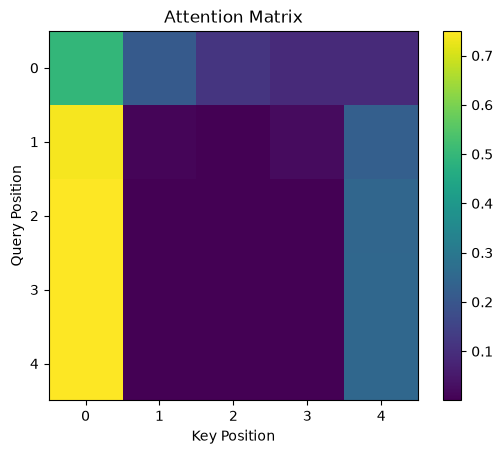

In [24]:
# VISUALIZE ATTENTION MATRIX

import matplotlib.pyplot as plt

attn = attn_weights[0].detach().numpy()

plt.imshow(attn, cmap="viridis")
plt.colorbar()

plt.title("Attention Matrix")

plt.xlabel("Key Position")
plt.ylabel("Query Position")

plt.show()

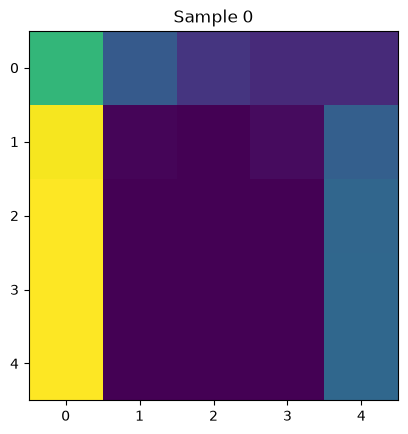

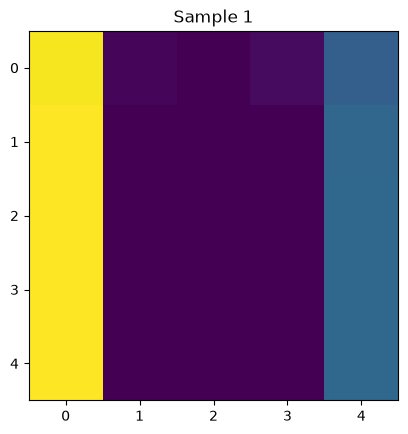

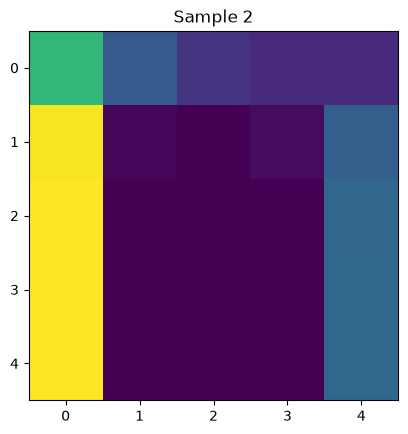

In [25]:
# MULTIPLE ATTENTION PATTERNS

for i in range(3):

    sample = X_torch[i:i+1]

    _, attn = model(sample)

    plt.imshow(attn[0].detach().numpy(), cmap="viridis")
    plt.title(f"Sample {i}")
    plt.show()

Dataset --> Tensor --> Transformer --> Training --> Evaluation --> Attention Visualization

## Why Transformers outperform RNN/LSTM

### 1. Parallel Computation

RNN:

    sequential --> slow

Transformer:

    parallel --> fast


### 2. Long-range dependencies

RNN:

    information degrades

Transformer:

    direct attention --> no degradation

### 3. Flexibility

Can model arbitrary relationships

### Key Insight

Transformer removes sequential bottleneck

## RNN vs LSTM vs Transformer

| Model | Memory | Speed | Long dependencies |
|------|------|------|----------------------|
| RNN | weak | slow | poor |
| LSTM | strong | slow | better |
| Transformer | attention | fast | excellent |

### Key Insight

Transformer = generalization of sequence learning